# Build matrix of interactions

In [ ]:
import os
import pandas as pd
from plip.structure.preparation import PDBComplex

# Protein names (longest first to avoid partial matches)
proteins = [
    "PDE4B_monomer_md",
    "PDE4B_dimer",
    "PDE4D_catalytic",
]

interaction_types = [
    "hydrophobic_contacts",
    "hbonds_ldon",
    "hbonds_pdon",
    "water_bridges",
    "saltbridge_lneg",
    "saltbridge_pneg",
    "pistacking",
    "pication_laro",
    "pication_paro",
    "halogen_bonds",
    "metal_complexes",
]

rows = []

pdb_folder = "../pdbs"

for pdb_file in sorted(os.listdir(pdb_folder)):
    print(pdb_file)
    if not pdb_file.endswith(".pdb"):
        continue

    basename = os.path.splitext(pdb_file)[0]

    # Identify protein and ligand from filename
    protein = None
    ligand = None
    for p in proteins:
        if basename.startswith(p + "_"):
            protein = p
            ligand = basename[len(p) + 1:]
            break

    if protein is None:
        print(f"Skipping {pdb_file}: protein not recognized.")
        continue

    pdb_path = os.path.join(pdb_folder, pdb_file)

    mol = PDBComplex()
    mol.load_pdb(pdb_path)
    mol.analyze()

    for bsid, inter in mol.interaction_sets.items():

        # # Ignore cofactors/ions (keep only the docked ligand)
        # if inter.ligand.hetid != "UNL":
        #     continue

        for interaction_type in interaction_types:

            if not hasattr(inter, interaction_type):
                continue

            interactions = getattr(inter, interaction_type)

            for i in interactions:

                rows.append({
                    "protein": protein,
                    "ligand": ligand,
                    "binding_site": bsid,
                    "interaction_type": interaction_type,
                    "residue_number": getattr(i, "resnr", None),
                    "residue_name": getattr(i, "restype", None),
                    "residue_chain": getattr(i, "reschain", None),
                })


PDE4B_catalytic_104775.pdb
PDE4B_catalytic_10559720.pdb
PDE4B_catalytic_107.pdb
PDE4B_catalytic_348154.pdb
PDE4B_catalytic_49831816.pdb
PDE4B_catalytic_6047.pdb
PDE4B_catalytic_Rrolipram_ph.pdb
PDE4B_catalytic_Srolipram_ph.pdb
PDE4B_catalytic_no12.pdb
PDE4B_catalytic_no13.pdb
PDE4B_catalytic_no17.pdb
PDE4B_catalytic_no7.pdb
PDE4B_catalytic_roflumilast.pdb
PDE4B_dimer_104775.pdb
PDE4B_dimer_10559720.pdb
PDE4B_dimer_107.pdb
PDE4B_dimer_348154.pdb
PDE4B_dimer_49831816.pdb
PDE4B_dimer_6047.pdb
PDE4B_dimer_Rrolipram_ph.pdb
PDE4B_dimer_Srolipram_ph.pdb
PDE4B_dimer_no12.pdb
PDE4B_dimer_no13.pdb
PDE4B_dimer_no17.pdb
PDE4B_dimer_no7.pdb
PDE4B_dimer_roflumilast.pdb
PDE4B_monomer_104775.pdb
PDE4B_monomer_10559720.pdb
PDE4B_monomer_107.pdb
PDE4B_monomer_348154.pdb
PDE4B_monomer_49831816.pdb
PDE4B_monomer_6047.pdb
PDE4B_monomer_Rrolipram_ph.pdb
PDE4B_monomer_Srolipram_ph.pdb
PDE4B_monomer_md_104775.pdb
PDE4B_monomer_md_10559720.pdb
PDE4B_monomer_md_107.pdb
PDE4B_monomer_md_348154.pdb
PDE4B_monomer_

In [ ]:
# convert the list of dict to df 
df = pd.DataFrame(rows)

# create res id column with name, position and chain
df["residue_id"] = (
    df["residue_name"].astype(str) +
    df["residue_number"].astype("Int64").astype(str) +
    ":" +
    df["residue_chain"].astype(str)
)

df.to_csv("protein_interactions.csv", index=False)


In [70]:
df = pd.read_csv('/home/gbiuser/Documents/vitoria/usp-masters/8-docking/interactions/protein_interactions.csv')    
print(df.shape)
print(df.columns)

(2599, 8)
Index(['protein', 'ligand', 'binding_site', 'interaction_type',
       'residue_number', 'residue_name', 'residue_chain', 'residue_id'],
      dtype='object')


# Analyses 


## Conserved residues across all complexes

In [77]:
# create df disconsindering ions
df_lig = df[df["binding_site"].str.startswith("UNL:")].copy()
to_remove = ["PDE4B_monomer", "PDE4B_catalytic"]
df_lig = df_lig[~df_lig["protein"].isin(to_remove)]


In [81]:
# aggregate number of interactions based on number of proteins and ligands 
conserved = (
    df_lig.groupby("residue_id")
            .agg(
                n_proteins=("protein", "nunique"),
                n_ligands=("ligand", "nunique"),
                n_complexes=("protein", lambda x: len(set(zip(x, df.loc[x.index, "ligand"])))),
            )         
            .reset_index()
)

In [82]:
conserved.sort_values("n_complexes", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
55,PHE373:A,1,13,13
53,PHE288:A,1,13,13
59,PHE538:A,1,13,13
57,PHE453:A,1,13,13
39,ILE502:A,1,13,13
37,ILE337:A,1,13,13
15,GLN370:A,1,12,12
18,GLN535:A,1,12,12
38,ILE417:A,2,12,12
36,ILE252:A,1,11,11


In [83]:
conserved.sort_values("n_proteins", ascending=False).head(20)

,residue_id,n_proteins,n_ligands,n_complexes
38,ILE417:A,2,12,12
17,GLN450:A,2,8,8
0,ARG411:A,1,3,3
1,ARG576:A,1,3,3
4,ASN290:A,1,1,1
5,ASN322:A,1,2,2
2,ASN125:A,1,1,1
3,ASN237:A,1,2,2
8,ASP234:A,1,2,2
9,ASP273:A,1,2,2


### Conserved only in PDE4B

In [85]:
PDE4B_subset = [
    "PDE4B_dimer",
    "PDE4B_monomer_md"
]

df_subset = df_lig[
    df_lig["protein"].isin(PDE4B_subset)
].copy()

conserved_PDE4B = (
    df_subset.groupby("residue_id")
             .agg(
                 n_proteins=("protein", "nunique"),
                 n_ligands=("ligand", "nunique"),
                 n_complexes=("protein", lambda x: len(set(zip(x, df_subset.loc[x.index, "ligand"]))))
             )
             .reset_index()
             .sort_values(
                 ["n_proteins", "n_ligands"],
                 ascending=False
             )
)

print(conserved_PDE4B.head(20))

   residue_id  n_proteins  n_ligands  n_complexes
23   ILE417:A           2         12           12
10   GLN450:A           2          8            8
32   PHE288:A           1         13           13
34   PHE453:A           1         13           13
22   ILE252:A           1         11           11
31   PHE256:A           1          9            9
33   PHE421:A           1          9            9
8    GLN285:A           1          8            8
5    ASN402:A           1          7            7
39   TYR240:A           1          7            7
16   HIS241:A           1          6            6
17   HIS245:A           1          6            6
42    TYR75:A           1          6            6
20    HIS76:A           1          5            5
28   MET273:A           1          4            4
30   MET438:A           1          4            4
0    ARG411:A           1          3            3
1    ARG576:A           1          3            3
7    ASP399:A           1          3            3


## Interaction fingerprint (IFP) analysis

In [64]:
fp_ligand = (
    df_lig.assign(value=1)
          .pivot_table(
              index="ligand",
              columns="residue_id",
              values="value",
              aggfunc="max",
              fill_value=0
          )
)


In [ ]:
known = ["Rrolipram", "roflumilast", "Srolipram"]

known_fp = fp_ligand.loc[known]

shared = known_fp.sum(axis=0) == len(known)


['GLN370:A', 'GLN450:A', 'GLN535:A', 'GLN615:A', 'HIS241:A', 'ILE337:A', 'ILE417:A', 'ILE502:A', 'ILE582:A', 'PHE256:A', 'PHE288:A', 'PHE373:A', 'PHE421:A', 'PHE453:A', 'PHE538:A', 'PHE586:A', 'PHE618:A', 'SER289:A', 'SER449:A', 'SER614:A', 'TYR240:A', 'TYR405:A']


### Clustering

In [ ]:
fp = (
    df_lig.assign(value=1)
           .pivot_table(
               index=["protein", "ligand"],
               columns="residue_id",
               values="value",
               aggfunc="max",
               fill_value=0
           )
)

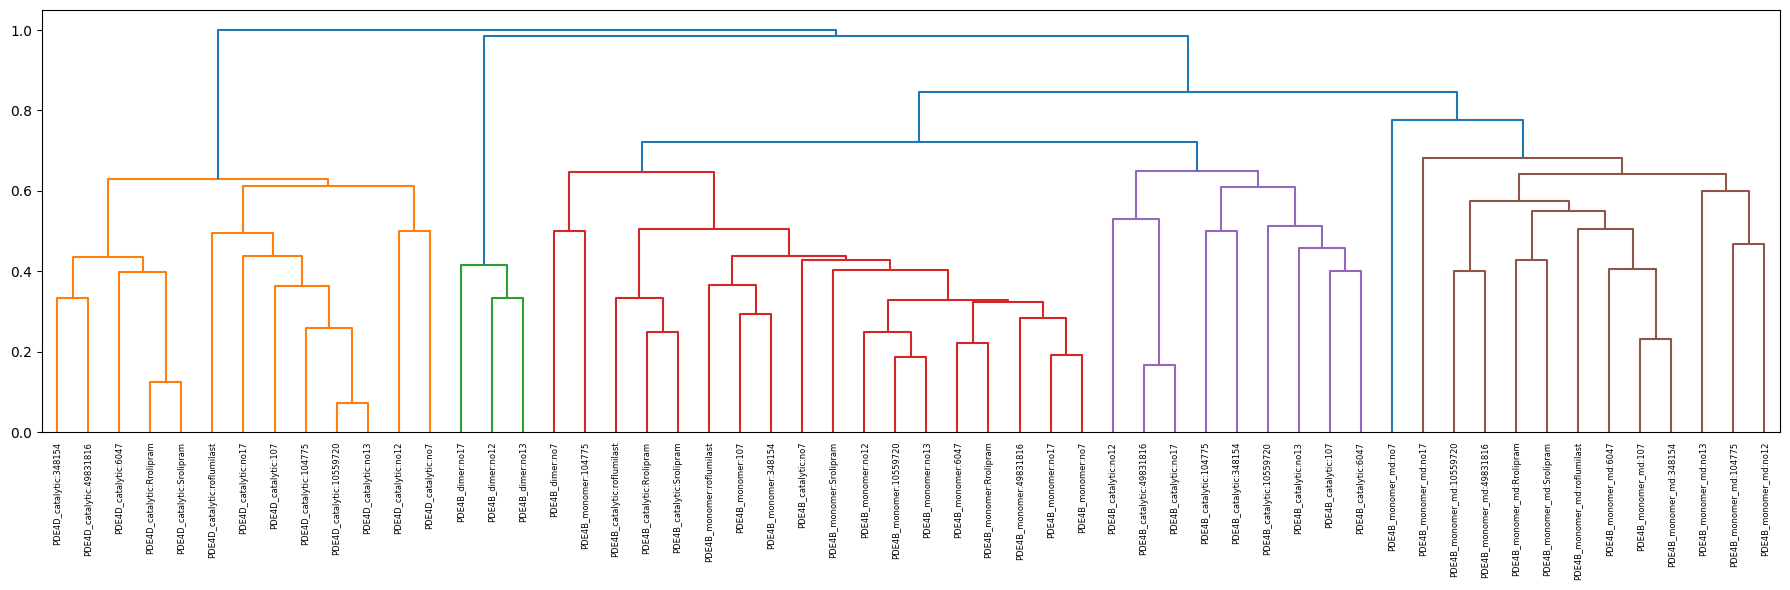

In [69]:
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance = pdist(fp.values, metric="jaccard")

Z = linkage(distance, method="average")

plt.figure(figsize=(18,6))

dendrogram(
    Z,
    labels=[f"{p}:{l}" for p, l in fp.index],
    leaf_rotation=90
)

plt.tight_layout()
plt.show()